In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv("../data/spam.csv", encoding='latin-1')


# Giữ lại cột v1,v2
df = df[['v1', 'v2']]

# Đổi tên cột
df.columns = ['label', 'message']

# Xóa duplicate
df = df.drop_duplicates()

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [21]:
# Thống kê spam và ham
print(df['label'].value_counts())

# Tính % spam
spam_percent = (df['label'].value_counts()['spam'] / len(df)) * 100

print("Spam percentage:", spam_percent)

label
ham     4516
spam     653
Name: count, dtype: int64
Spam percentage: 12.633004449603405


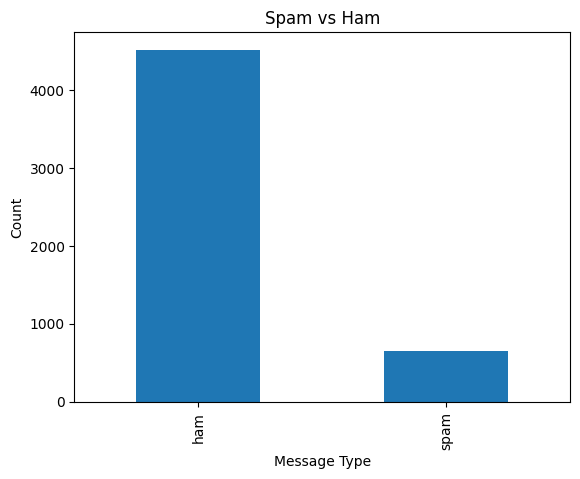

In [22]:
df['label'].value_counts().plot(kind='bar')

plt.title("Spam vs Ham")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

In [23]:
# Độ dài tin nhắn
df['message_length'] = df['message'].apply(len)

print(df.head())

# So sánh độ dài trung bình
print(df.groupby('label')['message_length'].mean())

  label                                            message  message_length
0   ham  Go until jurong point, crazy.. Available only ...             111
1   ham                      Ok lar... Joking wif u oni...              29
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...             155
3   ham  U dun say so early hor... U c already then say...              49
4   ham  Nah I don't think he goes to usf, he lives aro...              61
label
ham      70.459256
spam    137.891271
Name: message_length, dtype: float64


In [34]:
import ssl
import nltk

ssl._create_default_https_context = ssl._create_unverified_context

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /Users/camlee05/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/camlee05/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/camlee05/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [35]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def transform_text(text):
    text = text.lower()
    text = word_tokenize(text)

    y = []

    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stop_words:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [36]:
print(transform_text("FREE entry!!! Win money now!!!"))

free entri win money


In [37]:
# preprocess toàn bộ dataset
df['processed_text'] = df['message'].apply(transform_text)

print(df[['message', 'processed_text']].head())

                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                      processed_text  
0  go jurong point crazi avail bugi n great world...  
1                              ok lar joke wif u oni  
2  free entri 2 wkli comp win fa cup final tkt 21...  
3                u dun say earli hor u c alreadi say  
4               nah think goe usf live around though  
